# Source-paper RSS gene-set comparison

**Objective.** Compare the source paper's Supplementary Table 5 AhR/RSS-prioritized genes against our local `mouse_new` DESeq2 outputs, bend-point membership, direction of change, and retained GO follow-up terms.

This closes the missing *apples-to-apples* analysis framework in the draft: the source study uses response-shift scores (`log2FC(cKO) - log2FC(control)`), while our workflow uses DESeq2 side-specific contrasts plus bend-point narrowing and GO/pathway-level interpretation. The notebook does not treat the weekly reports as evidence; it uses the source paper supplement and local analysis tables as data inputs.

**Status rule.** Keep the manuscript checklist item **OPEN / IN PROGRESS** until these generated tables are inserted into the Results/Discussion text and reviewed in the paper draft.

## Inputs and outputs

**Required source input**
- Nature article: <https://www.nature.com/articles/s41586-026-10295-z>
- Supplementary Tables XLSX: downloaded from the article's Springer supplementary-material endpoint.
- Target sheet: `Table S5`, labelled by Nature as shifted genes in AhR cKO versus control DRGs after peripheral lesion.

**Local workflow inputs**
- WT/FF and CRE/cKO DESeq2 full and significant side-specific tables.
- WT/FF 709-gene and CRE/cKO 870-gene bend-point sets.
- Retained g:Profiler/GO membership tables for WT/FF and CRE/cKO follow-up.

**Generated outputs**
- `source_rss_comparison_summary.tsv`
- `source_rss_direction_summary.tsv`
- `source_rss_gene_level_comparison.tsv`
- `source_rss_branch_membership_matrix.tsv`
- `source_rss_agreement_statistics.tsv`
- `source_rss_go_membership_overlap.tsv`
- `source_rss_go_term_summary.tsv`
- `source_rss_go_term_comparison.tsv`
- `source_rss_apples_to_apples_comparison_panel.png`
- `source_rss_delta_scatter.png`
- `source_rss_control_lfc_scatter.png`
- `source_rss_cko_lfc_scatter.png`
- `source_rss_bendpoint_venn_style.png`
- `source_rss_go_term_overlap_scatter.png`
- `source_rss_membership_matrix.png`
- `source_rss_comparison_summary.md`

## Transcript-driven figure design note

The first pass produced the right counts, but the single bar chart did not really compare the source study with our workflow. For this revision, the notebook follows the recurring class/team guidance from the April transcript package:

- keep the story focused rather than exhaustive;
- use figures that help a reader understand the result, not figures that merely show that more output exists;
- compare analyses at the gene-support level when possible, because GO labels alone can hide whether the same genes support the theme;
- separate views when one combined graphic becomes too busy.

That leads to a small figure set: fold-change agreement scatter plots, a direct RSS-vs-local-delta scatter plot, Venn-style membership views, and a branch-membership matrix that distinguishes shared, WT-only, cKO-only, significant-only, and unmatched source-paper genes.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
SOURCE_DIR = ROOT / 'understanding' / 'source_paper'
OUTPUT_DIR = ROOT / 'preparation' / 'DE-derived_analysis' / 'source_paper_rss_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

ARTICLE_URL = 'https://www.nature.com/articles/s41586-026-10295-z'
SUPPLEMENT_URL = 'https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10295-z/MediaObjects/41586_2026_10295_MOESM3_ESM.xlsx'
SUPPLEMENT_XLSX = SOURCE_DIR / '41586_2026_10295_MOESM3_ESM_supplementary_tables.xlsx'

DE_TABLE_DIR = ROOT / 'preparation' / 'DE-family_drg_novaseqx' / 'tables'
DERIVED_DIR = ROOT / 'preparation' / 'DE-derived_analysis'

PATHS = {
    'wt_full': DE_TABLE_DIR / 'ipsi_vs_contra_in_ff_full.tsv',
    'cko_full': DE_TABLE_DIR / 'ipsi_vs_contra_in_cre_full.tsv',
    'wt_significant': DE_TABLE_DIR / 'ipsi_vs_contra_in_ff_significant.tsv',
    'cko_significant': DE_TABLE_DIR / 'ipsi_vs_contra_in_cre_significant.tsv',
    'wt_bendpoint': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'selected_genes_bendpoint.tsv',
    'cko_bendpoint': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'selected_genes_bendpoint.tsv',
    'wt_go_up': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'shinygo_style' / 'gprofiler_up_term_gene_membership.tsv',
    'wt_go_down': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'shinygo_style' / 'gprofiler_down_term_gene_membership.tsv',
    'cko_go_up': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'shinygo_style_shared' / 'gprofiler_up_term_gene_membership.tsv',
    'cko_go_down': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'shinygo_style_shared' / 'gprofiler_down_term_gene_membership.tsv',
    'wt_anchors': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'anchor_genes_up_down.tsv',
    'cko_anchors': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'anchor_genes_up_down.tsv',
}

pd.set_option('display.max_colwidth', 120)
print('Output directory:', OUTPUT_DIR)

Output directory: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/preparation/DE-derived_analysis/source_paper_rss_comparison


In [2]:
import subprocess
import sys

def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(path)
    return path

if not SUPPLEMENT_XLSX.exists():
    print('Downloading source-paper supplementary tables...')
    urlretrieve(SUPPLEMENT_URL, SUPPLEMENT_XLSX)

for label, path in PATHS.items():
    require_file(path)

try:
    xl = pd.ExcelFile(SUPPLEMENT_XLSX, engine='openpyxl')
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    xl = pd.ExcelFile(SUPPLEMENT_XLSX, engine='openpyxl')
print('Supplement sheets:', xl.sheet_names)
print('Supplement file:', SUPPLEMENT_XLSX)
print('All local workflow inputs found.')

Supplement sheets: ['Table S1', 'Table S2', 'Table S3', 'Table S4', 'Table S5', 'Table S6', 'Table S7', 'Table S8', 'Table S9']
Supplement file: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/understanding/source_paper/41586_2026_10295_MOESM3_ESM_supplementary_tables.xlsx
All local workflow inputs found.


## 1. Load Supplementary Table 5 and source-paper identifier map

`Table S5` contains gene symbols and source-paper RSS values, but not Ensembl IDs. To match against our DESeq2 outputs, this notebook builds a source-paper symbol-to-Ensembl map from Supplementary Tables 1 and 2, strips Ensembl version suffixes, and then joins those IDs to our local DESeq2 tables.

In [3]:
def normalize_symbol(value):
    return str(value).strip().upper()

source_s5 = pd.read_excel(SUPPLEMENT_XLSX, sheet_name='Table S5')
source_s5 = source_s5.rename(columns={
    'Gene symbol': 'source_gene_symbol',
    'log2FC_Ctrl': 'source_log2fc_control',
    'adj_p_Ctrl (ipsi vs. contra)': 'source_padj_control',
    'log2FC_cKO': 'source_log2fc_cko',
    'adj_p_cKO (ipsi vs. contra)': 'source_padj_cko',
    'shift: log2FC cKO- log2 FC Ctrl': 'source_rss_shift',
})[
    ['source_gene_symbol', 'source_log2fc_control', 'source_padj_control',
     'source_log2fc_cko', 'source_padj_cko', 'source_rss_shift']
]
source_s5['source_symbol_norm'] = source_s5['source_gene_symbol'].map(normalize_symbol)
source_s5['source_rss_sign'] = np.sign(source_s5['source_rss_shift']).map({-1: 'negative', 0: 'zero', 1: 'positive'})
source_s5['source_rss_abs_ge_0_3'] = source_s5['source_rss_shift'].abs() >= 0.3

source_maps = []
for sheet_name in ['Table S1', 'Table S2']:
    sheet = pd.read_excel(SUPPLEMENT_XLSX, sheet_name=sheet_name, usecols=['gene symbol', 'id'])
    sheet = sheet.rename(columns={'gene symbol': 'source_gene_symbol', 'id': 'source_ensembl_versioned'})
    sheet['source_symbol_norm'] = sheet['source_gene_symbol'].map(normalize_symbol)
    sheet['source_gene_id'] = sheet['source_ensembl_versioned'].astype(str).str.replace(r'\.\d+$', '', regex=True)
    source_maps.append(sheet[['source_symbol_norm', 'source_gene_id', 'source_ensembl_versioned']])

source_id_map = pd.concat(source_maps, ignore_index=True).drop_duplicates()
source_id_map = source_id_map[source_id_map['source_gene_id'].str.startswith('ENSMUSG', na=False)]
source_id_counts = source_id_map.groupby('source_symbol_norm')['source_gene_id'].nunique().rename('n_source_gene_ids').reset_index()

source_long = (
    source_s5
    .merge(source_id_map, on='source_symbol_norm', how='left')
    .merge(source_id_counts, on='source_symbol_norm', how='left')
)
source_long['source_mapping_status'] = np.select(
    [source_long['source_gene_id'].isna(), source_long['n_source_gene_ids'].fillna(0) > 1],
    ['unmapped', 'ambiguous_symbol'],
    default='unique_symbol',
)

reported_counts = source_s5['source_rss_sign'].value_counts().to_dict()
validation = {
    'source_table_rows': len(source_s5),
    'source_unique_symbols': source_s5['source_symbol_norm'].nunique(),
    'positive_rss': int(reported_counts.get('positive', 0)),
    'negative_rss': int(reported_counts.get('negative', 0)),
    'symbols_with_source_ensembl_id': int(source_long.dropna(subset=['source_gene_id'])['source_symbol_norm'].nunique()),
    'ambiguous_symbols': int((source_long.groupby('source_symbol_norm')['source_gene_id'].nunique() > 1).sum()),
}
display(pd.Series(validation, name='value').to_frame())

assert validation['source_table_rows'] == 1431, 'Expected 1,431 RSS genes from Supplementary Table 5.'
assert validation['positive_rss'] == 533 and validation['negative_rss'] == 898, 'RSS sign counts do not match article text.'

,value
source_table_rows,1431
source_unique_symbols,1431
positive_rss,533
negative_rss,898
symbols_with_source_ensembl_id,1431
ambiguous_symbols,8


## 2. Load local DESeq2, bend-point, GO, and anchor-gene outputs

The local analysis uses reader-facing `WT`/`cKO` language, while the original file names still carry the project labels `FF`/`CRE`. Here, `WT/FF` and `cKO/CRE` refer to the same two genotype branches used in the draft.

In [4]:
def read_tsv(path):
    return pd.read_csv(path, sep='	')

wt_full = read_tsv(PATHS['wt_full']).rename(columns={
    'baseMean': 'our_baseMean_wt',
    'log2FoldChange': 'our_log2fc_wt',
    'pvalue': 'our_pvalue_wt',
    'padj': 'our_padj_wt',
})
cko_full = read_tsv(PATHS['cko_full']).rename(columns={
    'baseMean': 'our_baseMean_cko',
    'log2FoldChange': 'our_log2fc_cko',
    'pvalue': 'our_pvalue_cko',
    'padj': 'our_padj_cko',
})

our_de = wt_full[['gene_id', 'our_baseMean_wt', 'our_log2fc_wt', 'our_pvalue_wt', 'our_padj_wt']].merge(
    cko_full[['gene_id', 'our_baseMean_cko', 'our_log2fc_cko', 'our_pvalue_cko', 'our_padj_cko']],
    on='gene_id',
    how='outer',
)
our_de['in_our_tested_universe'] = our_de[['our_padj_wt', 'our_padj_cko', 'our_pvalue_wt', 'our_pvalue_cko']].notna().any(axis=1)
our_de['significant_wt_side'] = our_de['our_padj_wt'].lt(0.05)
our_de['significant_cko_side'] = our_de['our_padj_cko'].lt(0.05)
our_de['our_delta_cko_minus_wt'] = our_de['our_log2fc_cko'] - our_de['our_log2fc_wt']
our_de['our_delta_sign'] = np.sign(our_de['our_delta_cko_minus_wt']).map({-1: 'negative', 0: 'zero', 1: 'positive'})

wt_bendpoint = read_tsv(PATHS['wt_bendpoint'])
cko_bendpoint = read_tsv(PATHS['cko_bendpoint'])
wt_set = set(wt_bendpoint['gene_id'])
cko_set = set(cko_bendpoint['gene_id'])
shared_set = wt_set & cko_set
wt_only_set = wt_set - cko_set
cko_only_set = cko_set - wt_set

go_membership_parts = []
for branch, direction, path_key in [
    ('WT/FF', 'up', 'wt_go_up'),
    ('WT/FF', 'down', 'wt_go_down'),
    ('cKO/CRE', 'up', 'cko_go_up'),
    ('cKO/CRE', 'down', 'cko_go_down'),
]:
    table = read_tsv(PATHS[path_key])
    table['branch'] = branch
    table['go_direction'] = direction
    go_membership_parts.append(table[['branch', 'go_direction', 'native', 'name', 'gene_id', 'symbol']])
go_membership = pd.concat(go_membership_parts, ignore_index=True).drop_duplicates()
go_gene_set = set(go_membership['gene_id'])

anchor_parts = []
for branch, path_key in [('WT/FF', 'wt_anchors'), ('cKO/CRE', 'cko_anchors')]:
    table = read_tsv(PATHS[path_key])
    table['branch'] = branch
    if 'Gene ID' in table.columns:
        table = table.rename(columns={'Gene ID': 'gene_id'})
    anchor_parts.append(table)
anchor_genes = pd.concat(anchor_parts, ignore_index=True).drop_duplicates(subset=['branch', 'gene_id'])
anchor_gene_set = set(anchor_genes['gene_id'])

local_counts = pd.DataFrame([
    {'local_set': 'DESeq2-tested gene universe', 'count': our_de['gene_id'].nunique()},
    {'local_set': 'WT/FF significant side-specific genes', 'count': int(our_de['significant_wt_side'].sum())},
    {'local_set': 'cKO/CRE significant side-specific genes', 'count': int(our_de['significant_cko_side'].sum())},
    {'local_set': 'WT/FF bend-point genes', 'count': len(wt_set)},
    {'local_set': 'cKO/CRE bend-point genes', 'count': len(cko_set)},
    {'local_set': 'Shared WT/cKO bend-point genes', 'count': len(shared_set)},
    {'local_set': 'WT-only bend-point genes', 'count': len(wt_only_set)},
    {'local_set': 'cKO-only bend-point genes', 'count': len(cko_only_set)},
    {'local_set': 'Genes appearing in retained GO memberships', 'count': len(go_gene_set)},
])
display(local_counts)

,local_set,count
0,DESeq2-tested gene universe,21481
1,WT/FF significant side-specific genes,7023
2,cKO/CRE significant side-specific genes,7541
3,WT/FF bend-point genes,709
4,cKO/CRE bend-point genes,870
5,Shared WT/cKO bend-point genes,620
6,WT-only bend-point genes,89
7,cKO-only bend-point genes,250
8,Genes appearing in retained GO memberships,775


## 3. Compare source RSS genes with our workflow outputs

Direction agreement is calculated as an RSS-like quantity in our workflow: `our_log2FC(cKO/CRE side contrast) - our_log2FC(WT/FF side contrast)`. A source RSS gene is directionally consistent when the sign of that local delta agrees with the sign of the source-paper RSS value.

In [5]:
comparison_long = (
    source_long
    .rename(columns={'source_gene_id': 'gene_id'})
    .merge(our_de, on='gene_id', how='left')
)

boolean_columns = [
    'matched_our_tested_universe',
    'significant_wt_side',
    'significant_cko_side',
    'present_wt_bendpoint',
    'present_cko_bendpoint',
    'present_shared_bendpoint',
    'present_wt_only_bendpoint',
    'present_cko_only_bendpoint',
    'direction_consistent_with_source_rss',
    'appears_in_retained_go_terms',
    'appears_in_anchor_gene_table',
]

comparison_long['matched_our_tested_universe'] = comparison_long['in_our_tested_universe'].fillna(False)
comparison_long['present_wt_bendpoint'] = comparison_long['gene_id'].isin(wt_set)
comparison_long['present_cko_bendpoint'] = comparison_long['gene_id'].isin(cko_set)
comparison_long['present_shared_bendpoint'] = comparison_long['gene_id'].isin(shared_set)
comparison_long['present_wt_only_bendpoint'] = comparison_long['gene_id'].isin(wt_only_set)
comparison_long['present_cko_only_bendpoint'] = comparison_long['gene_id'].isin(cko_only_set)
comparison_long['appears_in_retained_go_terms'] = comparison_long['gene_id'].isin(go_gene_set)
comparison_long['appears_in_anchor_gene_table'] = comparison_long['gene_id'].isin(anchor_gene_set)
comparison_long['direction_consistent_with_source_rss'] = (
    comparison_long['matched_our_tested_universe']
    & (comparison_long['our_delta_sign'] == comparison_long['source_rss_sign'])
)

for column in boolean_columns:
    comparison_long[column] = comparison_long[column].fillna(False).astype(bool)

# Collapse to one row per source-paper gene symbol for paper-level counts.
symbol_level_flags = comparison_long.groupby('source_symbol_norm')[boolean_columns].any().reset_index()
source_symbol_level = source_s5.drop_duplicates('source_symbol_norm').merge(
    symbol_level_flags,
    on='source_symbol_norm',
    how='left',
)
for column in boolean_columns:
    source_symbol_level[column] = source_symbol_level[column].fillna(False).astype(bool)

summary_rows = [
    ('Source-paper AhR/RSS-prioritized genes', len(source_symbol_level), 'Genes identified by the source paper using |RSS| >= 0.3 in Supplementary Table 5.'),
    ('Found in our DESeq2-tested gene universe', source_symbol_level['matched_our_tested_universe'].sum(), 'Confirms identifier matching/overlap with the count matrix used for our DESeq2 side-specific contrasts.'),
    ('Significant in our WT side-specific contrast', source_symbol_level['significant_wt_side'].sum(), 'Source-paper RSS genes with adjusted p-value support in our WT/FF ipsilateral-vs-contralateral branch.'),
    ('Significant in our cKO side-specific contrast', source_symbol_level['significant_cko_side'].sum(), 'Source-paper RSS genes with adjusted p-value support in our CRE/cKO ipsilateral-vs-contralateral branch.'),
    ('Present in WT bend-point set', source_symbol_level['present_wt_bendpoint'].sum(), 'Source-paper RSS genes recovered in the 709-gene WT/FF bend-point follow-up set.'),
    ('Present in cKO bend-point set', source_symbol_level['present_cko_bendpoint'].sum(), 'Source-paper RSS genes recovered in the 870-gene CRE/cKO bend-point follow-up set.'),
    ('Present in WT/cKO shared 620-gene set', source_symbol_level['present_shared_bendpoint'].sum(), 'RSS genes that fall in the shared injury-response backbone retained by both bend-point branches.'),
    ('Present in cKO-only 250-gene set', source_symbol_level['present_cko_only_bendpoint'].sum(), 'RSS genes that may support cKO-specific interpretation beyond the shared injury-response core.'),
    ('Present in WT-only 89-gene set', source_symbol_level['present_wt_only_bendpoint'].sum(), 'RSS genes that appear only in the WT/FF bend-point follow-up subset.'),
    ('Directionally consistent with RSS sign', source_symbol_level['direction_consistent_with_source_rss'].sum(), 'Matched genes where sign(source RSS) agrees with sign(our cKO/CRE log2FC minus our WT/FF log2FC).'),
    ('Appearing in retained GO follow-up terms', source_symbol_level['appears_in_retained_go_terms'].sum(), 'RSS genes that appear in at least one retained g:Profiler/GO membership table used for pathway-level interpretation.'),
    ('Appearing in anchor-gene follow-up tables', source_symbol_level['appears_in_anchor_gene_table'].sum(), 'RSS genes that overlap the branch-level anchor-gene tables used to explain leading signals.'),
]
summary = pd.DataFrame(summary_rows, columns=['metric', 'count', 'interpretation'])

direction_summary = source_symbol_level.groupby('source_rss_sign').agg(
    source_genes=('source_symbol_norm', 'count'),
    found_in_our_universe=('matched_our_tested_universe', 'sum'),
    wt_bendpoint=('present_wt_bendpoint', 'sum'),
    cko_bendpoint=('present_cko_bendpoint', 'sum'),
    shared_bendpoint=('present_shared_bendpoint', 'sum'),
    cko_only_bendpoint=('present_cko_only_bendpoint', 'sum'),
    wt_only_bendpoint=('present_wt_only_bendpoint', 'sum'),
    direction_consistent=('direction_consistent_with_source_rss', 'sum'),
    in_go_terms=('appears_in_retained_go_terms', 'sum'),
).reset_index()

display(summary)
display(direction_summary)

,metric,count,interpretation
0,Source-paper AhR/RSS-prioritized genes,1431,Genes identified by the source paper using |RSS| >= 0.3 in Supplementary Table 5.
1,Found in our DESeq2-tested gene universe,1025,Confirms identifier matching/overlap with the count matrix used for our DESeq2 side-specific contrasts.
2,Significant in our WT side-specific contrast,473,Source-paper RSS genes with adjusted p-value support in our WT/FF ipsilateral-vs-contralateral branch.
3,Significant in our cKO side-specific contrast,577,Source-paper RSS genes with adjusted p-value support in our CRE/cKO ipsilateral-vs-contralateral branch.
4,Present in WT bend-point set,43,Source-paper RSS genes recovered in the 709-gene WT/FF bend-point follow-up set.
5,Present in cKO bend-point set,45,Source-paper RSS genes recovered in the 870-gene CRE/cKO bend-point follow-up set.
6,Present in WT/cKO shared 620-gene set,34,RSS genes that fall in the shared injury-response backbone retained by both bend-point branches.
7,Present in cKO-only 250-gene set,11,RSS genes that may support cKO-specific interpretation beyond the shared injury-response core.
8,Present in WT-only 89-gene set,9,RSS genes that appear only in the WT/FF bend-point follow-up subset.
9,Directionally consistent with RSS sign,987,Matched genes where sign(source RSS) agrees with sign(our cKO/CRE log2FC minus our WT/FF log2FC).


,source_rss_sign,source_genes,found_in_our_universe,wt_bendpoint,cko_bendpoint,shared_bendpoint,cko_only_bendpoint,wt_only_bendpoint,direction_consistent,in_go_terms
0,negative,898,679,14,9,7,2,7,662,13
1,positive,533,346,29,36,27,9,2,325,34


## 4. Build GO overlap tables

These tables identify which source-paper RSS genes also appear inside the retained pathway-level interpretation tables. They should be used to support wording such as “related biological themes are present, but the exact RSS gene set was only partially recovered by our bend-point follow-up.”

In [6]:
rss_gene_ids_found = set(comparison_long.loc[comparison_long['matched_our_tested_universe'], 'gene_id'])

go_overlap = (
    go_membership[go_membership['gene_id'].isin(rss_gene_ids_found)]
    .drop_duplicates()
    .sort_values(['branch', 'go_direction', 'native', 'gene_id'])
)

go_term_summary = (
    go_overlap
    .groupby(['branch', 'go_direction', 'native', 'name'], as_index=False)
    .agg(
        rss_gene_count=('gene_id', 'nunique'),
        example_rss_genes=('symbol', lambda values: ', '.join(sorted(set(map(str, values)))[:8])),
    )
    .sort_values(['rss_gene_count', 'branch'], ascending=[False, True])
)

display(go_term_summary.head(20))

,branch,go_direction,native,name,rss_gene_count,example_rss_genes
410,cKO/CRE,up,GO:0009987,cellular process,33,"2210017I01Rik, Adm2, Ankrd1, Cckbr, Clca1, Dusp9, ENSMUSG00000025279, ENSMUSG00000030223"
80,WT/FF,up,GO:0009987,cellular process,32,"2210017I01Rik, Adm2, Ankrd1, Cckbr, Ccn4, Cited2, Clca1, Dusp9"
562,cKO/CRE,up,GO:0050896,response to stimulus,30,"Adm2, Ankrd1, Bpifc, Cckbr, Cd207, Clca1, Dusp9, ENSMUSG00000025279"
279,WT/FF,up,GO:0065007,biological regulation,29,"Adm2, Angptl2, Ankrd1, Cckbr, Ccn4, Cited2, Dusp9, Ecel1"
601,cKO/CRE,up,GO:0065007,biological regulation,29,"Adm2, Ankrd1, Cckbr, Dusp9, ENSMUSG00000025279, ENSMUSG00000030223, ENSMUSG00000051209, ENSMUSG00000061947"
240,WT/FF,up,GO:0050896,response to stimulus,28,"Adm2, Angptl2, Ankrd1, Bpifc, Cckbr, Ccn4, Cd207, Cited2"
236,WT/FF,up,GO:0050789,regulation of biological process,27,"Adm2, Ankrd1, Cckbr, Ccn4, Cited2, Dusp9, Ecel1, Fgf3"
556,cKO/CRE,up,GO:0050789,regulation of biological process,27,"Adm2, Ankrd1, Cckbr, Dusp9, ENSMUSG00000025279, ENSMUSG00000030223, ENSMUSG00000051209, ENSMUSG00000067006"
142,WT/FF,up,GO:0032501,multicellular organismal process,25,"2210017I01Rik, Adm2, Angptl2, Ankrd1, Cckbr, Ccn4, Cited2, Ecel1"
238,WT/FF,up,GO:0050794,regulation of cellular process,25,"Adm2, Ankrd1, Cckbr, Ccn4, Cited2, Dusp9, Ecel1, Fgf3"


## 5. Research-grade comparison figures

The figures below are meant to make the comparison readable rather than merely counted. They answer three different questions:

1. **Do the same genes move in similar directions?** Scatter plots compare source-study log2FC/RSS values with our DESeq2 log2FC/RSS-like values.
2. **Which source-paper genes survive our stricter bend-point narrowing?** Venn-style plots show overlap with the WT/FF and cKO/CRE branch sets.
3. **Where do source-paper genes land in our pathway-level interpretation?** A membership matrix and GO-term overlap scatter connect source RSS genes to retained GO memberships.

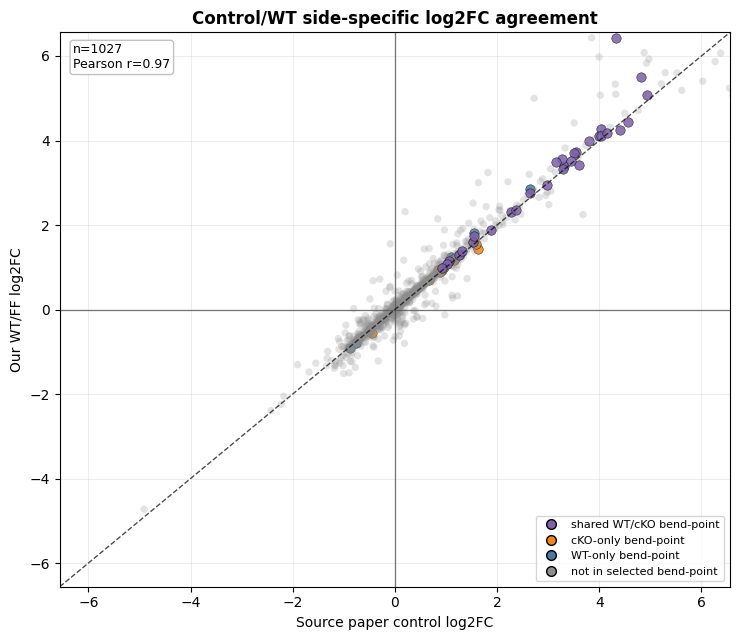

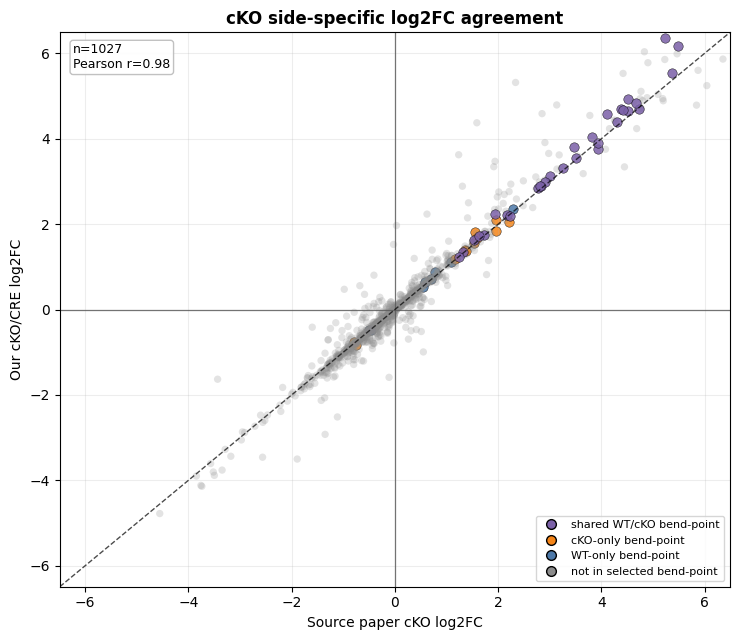

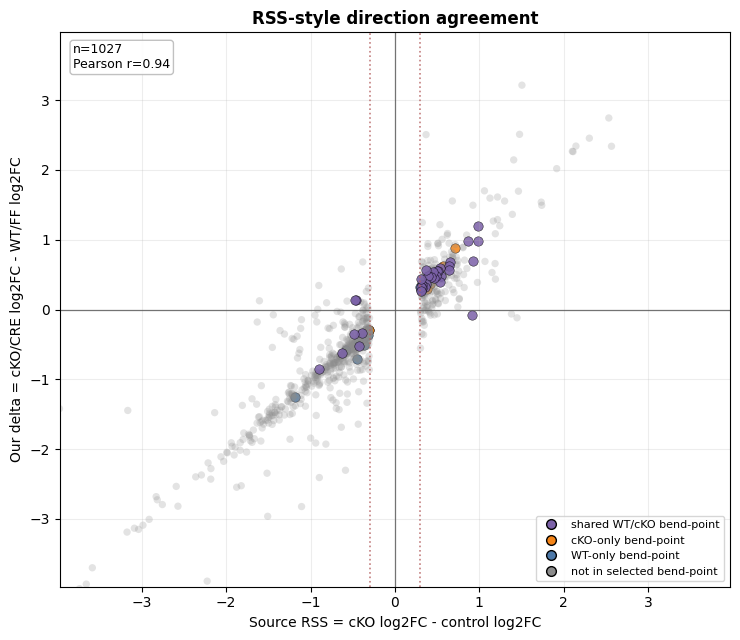

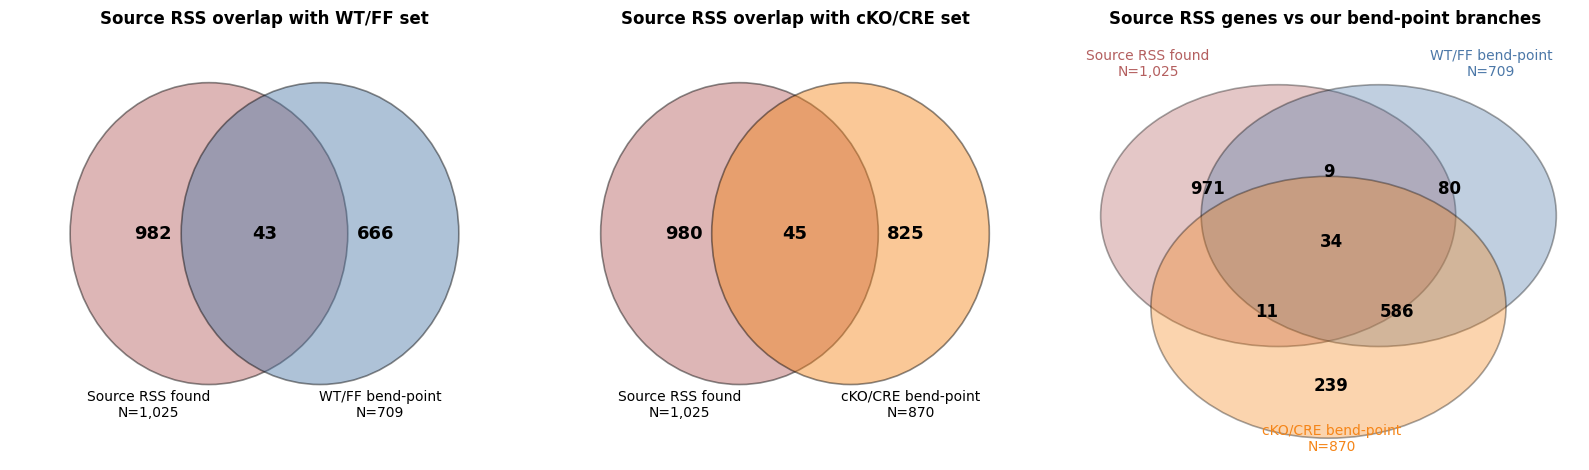

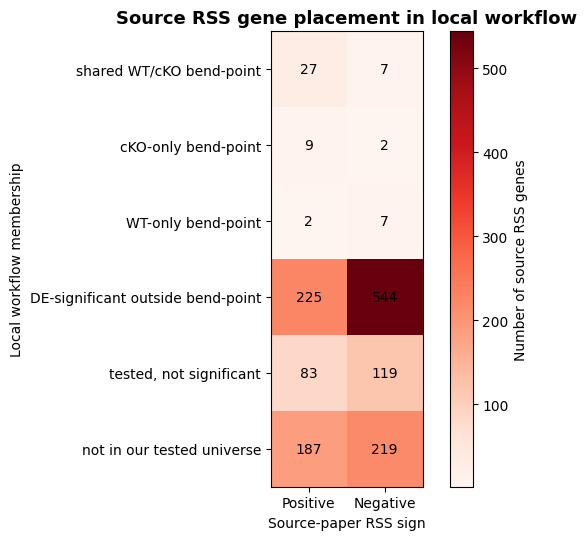

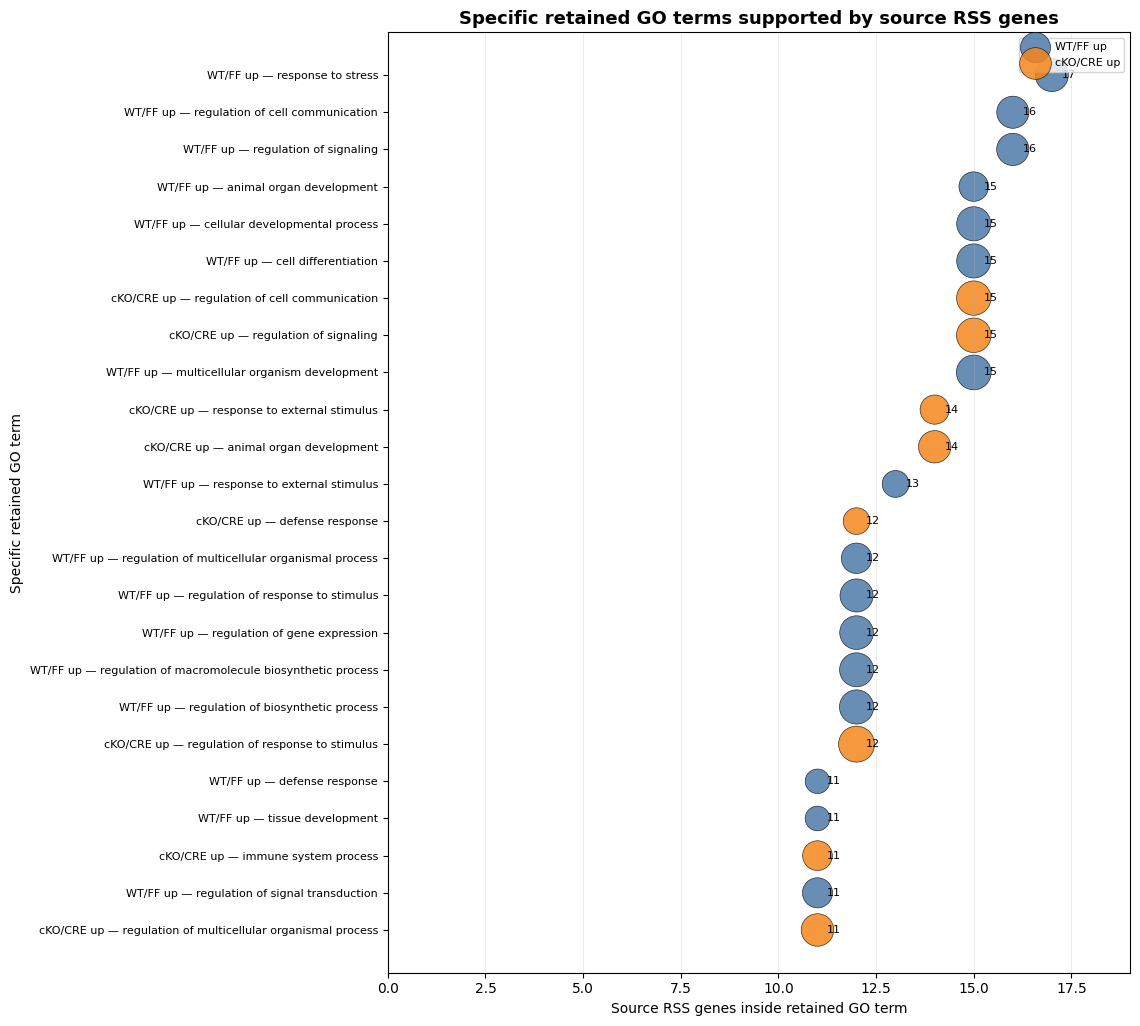

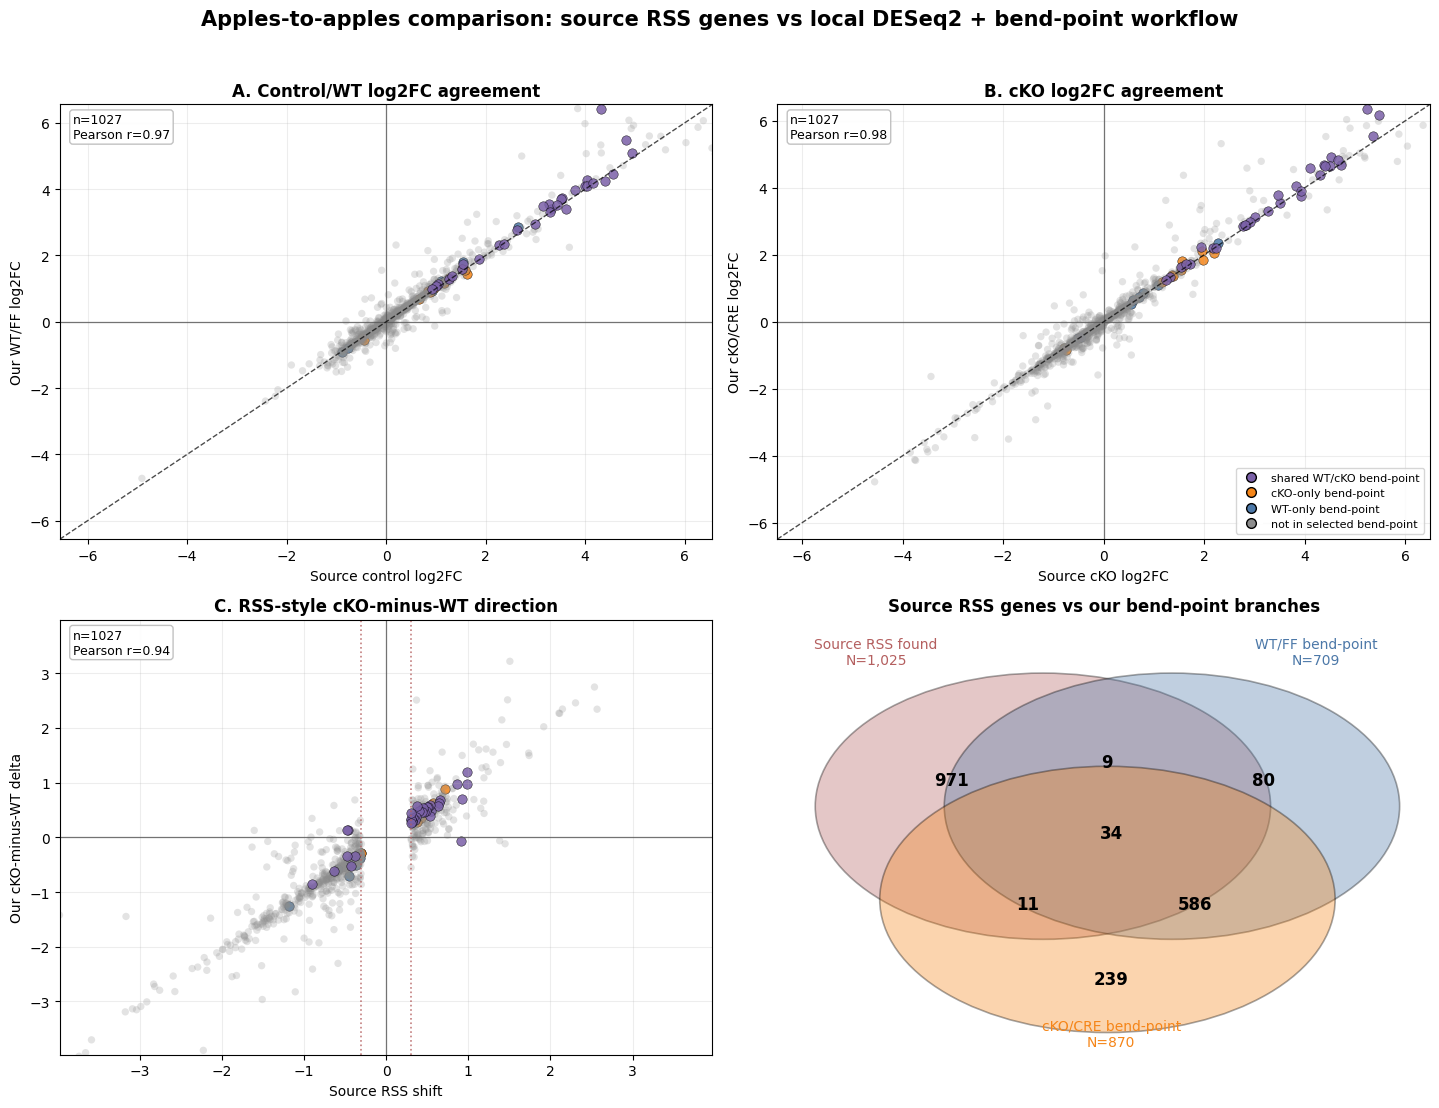

### Agreement statistics

,comparison,n_gene_id_rows,pearson_r,spearman_r,directional_agreement_fraction,directionally_consistent_symbols
0,Source control log2FC vs our WT/FF log2FC,1027,0.973830,0.963626,NaN,NaN
1,Source cKO log2FC vs our cKO/CRE log2FC,1027,0.978592,0.962722,NaN,NaN
2,Source RSS shift vs our cKO-minus-WT log2FC delta,1027,0.940980,0.916219,NaN,NaN
3,RSS sign agreement among matched source symbols,1025,NaN,NaN,0.962927,987.0


### Membership matrix

source_rss_sign,positive,negative
analysis_membership,,
shared WT/cKO bend-point,27,7
cKO-only bend-point,9,2
WT-only bend-point,2,7
DE-significant outside bend-point,225,544
"tested, not significant",83,119
not in our tested universe,187,219


In [7]:

from matplotlib.patches import Circle
from matplotlib.lines import Line2D

PITER_RED = '#b45f5f'
WT_BLUE = '#4C78A8'
CKO_ORANGE = '#F58518'
SHARED_PURPLE = '#7B61A8'
GREY = '#8C8C8C'
LIGHT_GREY = '#F2F2F2'

membership_palette = {
    'shared WT/cKO bend-point': SHARED_PURPLE,
    'cKO-only bend-point': CKO_ORANGE,
    'WT-only bend-point': WT_BLUE,
    'not in selected bend-point': GREY,
}

def classify_branch_membership(row):
    if row.get('present_shared_bendpoint', False):
        return 'shared WT/cKO bend-point'
    if row.get('present_cko_only_bendpoint', False):
        return 'cKO-only bend-point'
    if row.get('present_wt_only_bendpoint', False):
        return 'WT-only bend-point'
    return 'not in selected bend-point'

plot_df = comparison_long.loc[
    comparison_long['matched_our_tested_universe']
    & comparison_long['source_rss_shift'].notna()
    & comparison_long['our_delta_cko_minus_wt'].notna()
].drop_duplicates(['source_symbol_norm', 'gene_id']).copy()
plot_df['branch_membership'] = plot_df.apply(classify_branch_membership, axis=1)

# Symbol-level branch class used for matrix-style summaries.
def classify_source_symbol(row):
    if not row['matched_our_tested_universe']:
        return 'not in our tested universe'
    if row['present_shared_bendpoint']:
        return 'shared WT/cKO bend-point'
    if row['present_cko_only_bendpoint']:
        return 'cKO-only bend-point'
    if row['present_wt_only_bendpoint']:
        return 'WT-only bend-point'
    if row['significant_wt_side'] or row['significant_cko_side']:
        return 'DE-significant outside bend-point'
    return 'tested, not significant'

source_symbol_level['analysis_membership'] = source_symbol_level.apply(classify_source_symbol, axis=1)
membership_order = [
    'shared WT/cKO bend-point',
    'cKO-only bend-point',
    'WT-only bend-point',
    'DE-significant outside bend-point',
    'tested, not significant',
    'not in our tested universe',
]
membership_matrix = pd.crosstab(
    source_symbol_level['analysis_membership'],
    source_symbol_level['source_rss_sign'],
).reindex(membership_order).fillna(0).astype(int)
membership_matrix = membership_matrix.reindex(columns=['positive', 'negative']).fillna(0).astype(int)
membership_matrix.to_csv(OUTPUT_DIR / 'source_rss_branch_membership_matrix.tsv', sep='\t')

# Agreement statistics for the manuscript/support docs.
def agreement_row(label, x_col, y_col, data=plot_df):
    clean = data[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'comparison': label,
        'n_gene_id_rows': int(len(clean)),
        'pearson_r': float(clean[x_col].corr(clean[y_col], method='pearson')),
        'spearman_r': float(clean[x_col].rank().corr(clean[y_col].rank(), method='pearson')),
    }

matched_symbols = int(source_symbol_level['matched_our_tested_universe'].sum())
consistent_symbols = int(source_symbol_level['direction_consistent_with_source_rss'].sum())
agreement_stats = pd.DataFrame([
    agreement_row('Source control log2FC vs our WT/FF log2FC', 'source_log2fc_control', 'our_log2fc_wt'),
    agreement_row('Source cKO log2FC vs our cKO/CRE log2FC', 'source_log2fc_cko', 'our_log2fc_cko'),
    agreement_row('Source RSS shift vs our cKO-minus-WT log2FC delta', 'source_rss_shift', 'our_delta_cko_minus_wt'),
    {
        'comparison': 'RSS sign agreement among matched source symbols',
        'n_gene_id_rows': matched_symbols,
        'pearson_r': np.nan,
        'spearman_r': np.nan,
        'directional_agreement_fraction': consistent_symbols / matched_symbols,
        'directionally_consistent_symbols': consistent_symbols,
    },
])
agreement_stats.to_csv(OUTPUT_DIR / 'source_rss_agreement_statistics.tsv', sep='\t', index=False)

def add_identity_limits(ax, x, y, identity=True, zero=True):
    values = pd.concat([x, y]).replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = np.nanpercentile(values, [1, 99])
    bound = max(abs(lo), abs(hi), 1)
    bound *= 1.08
    ax.set_xlim(-bound, bound)
    ax.set_ylim(-bound, bound)
    if zero:
        ax.axhline(0, color='#555555', lw=0.9, alpha=0.8)
        ax.axvline(0, color='#555555', lw=0.9, alpha=0.8)
    if identity:
        ax.plot([-bound, bound], [-bound, bound], color='black', ls='--', lw=1, alpha=0.7)
    ax.grid(alpha=0.22)


def scatter_panel(ax, data, x_col, y_col, title, xlabel, ylabel, identity=True, rss_threshold=False):
    for label, group in data.groupby('branch_membership'):
        ax.scatter(
            group[x_col], group[y_col],
            s=28 if label == 'not in selected bend-point' else 46,
            alpha=0.24 if label == 'not in selected bend-point' else 0.86,
            color=membership_palette.get(label, GREY),
            edgecolor='black' if label != 'not in selected bend-point' else 'none',
            linewidth=0.35,
            label=label,
        )
    add_identity_limits(ax, data[x_col], data[y_col], identity=identity, zero=True)
    if rss_threshold:
        ax.axvline(-0.3, color=PITER_RED, ls=':', lw=1.2, alpha=0.8)
        ax.axvline(0.3, color=PITER_RED, ls=':', lw=1.2, alpha=0.8)
    corr = data[[x_col, y_col]].dropna()[x_col].corr(data[[x_col, y_col]].dropna()[y_col], method='pearson')
    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(
        0.02, 0.98,
        f'n={data[[x_col, y_col]].dropna().shape[0]}\nPearson r={corr:.2f}',
        transform=ax.transAxes,
        va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#BBBBBB', alpha=0.9),
    )

# Standalone scatter plots.
for filename, x_col, y_col, title, xlabel, ylabel, identity, threshold in [
    ('source_rss_control_lfc_scatter.png', 'source_log2fc_control', 'our_log2fc_wt', 'Control/WT side-specific log2FC agreement', 'Source paper control log2FC', 'Our WT/FF log2FC', True, False),
    ('source_rss_cko_lfc_scatter.png', 'source_log2fc_cko', 'our_log2fc_cko', 'cKO side-specific log2FC agreement', 'Source paper cKO log2FC', 'Our cKO/CRE log2FC', True, False),
    ('source_rss_delta_scatter.png', 'source_rss_shift', 'our_delta_cko_minus_wt', 'RSS-style direction agreement', 'Source RSS = cKO log2FC - control log2FC', 'Our delta = cKO/CRE log2FC - WT/FF log2FC', False, True),
]:
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    scatter_panel(ax, plot_df, x_col, y_col, title, xlabel, ylabel, identity=identity, rss_threshold=threshold)
    handles = [Line2D([0], [0], marker='o', color='w', label=k, markerfacecolor=v, markeredgecolor='black', markersize=7) for k, v in membership_palette.items()]
    ax.legend(handles=handles, loc='lower right', fontsize=8, frameon=True)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=300)
    plt.show()

# Venn-style plots using the same visual grammar as the FF/CRE branch-comparison notebook outputs.
def draw_two_set_venn(ax, left_label, right_label, left_total, right_total, overlap, left_color, right_color, title):
    left_only = left_total - overlap
    right_only = right_total - overlap
    ax.add_patch(Circle((0.43, 0.50), 0.30, color=left_color, alpha=0.45, ec='black', lw=1.2))
    ax.add_patch(Circle((0.67, 0.50), 0.30, color=right_color, alpha=0.45, ec='black', lw=1.2))
    ax.text(0.31, 0.50, f'{left_only:,}', ha='center', va='center', fontsize=13, weight='bold')
    ax.text(0.55, 0.50, f'{overlap:,}', ha='center', va='center', fontsize=13, weight='bold')
    ax.text(0.79, 0.50, f'{right_only:,}', ha='center', va='center', fontsize=13, weight='bold')
    ax.text(0.30, 0.16, f'{left_label}\nN={left_total:,}', ha='center', va='center', fontsize=10)
    ax.text(0.80, 0.16, f'{right_label}\nN={right_total:,}', ha='center', va='center', fontsize=10)
    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0.05, 0.9)
    ax.axis('off')


def draw_three_set_venn(ax):
    source_total = int(source_symbol_level['matched_our_tested_universe'].sum())
    source_wt = int(source_symbol_level['present_wt_bendpoint'].sum())
    source_cko = int(source_symbol_level['present_cko_bendpoint'].sum())
    source_shared = int(source_symbol_level['present_shared_bendpoint'].sum())
    wt_total = len(wt_set)
    cko_total = len(cko_set)
    wt_cko_shared = len(shared_set)

    source_only = source_total - source_wt - source_cko + source_shared
    source_wt_only = source_wt - source_shared
    source_cko_only = source_cko - source_shared
    wt_cko_not_source = wt_cko_shared - source_shared
    wt_only_not_source = wt_total - wt_cko_shared - source_wt_only
    cko_only_not_source = cko_total - wt_cko_shared - source_cko_only

    ax.add_patch(Circle((0.43, 0.56), 0.30, color=PITER_RED, alpha=0.35, ec='black', lw=1.2))
    ax.add_patch(Circle((0.60, 0.56), 0.30, color=WT_BLUE, alpha=0.35, ec='black', lw=1.2))
    ax.add_patch(Circle((0.515, 0.35), 0.30, color=CKO_ORANGE, alpha=0.35, ec='black', lw=1.2))
    labels = [
        (0.31, 0.62, source_only),
        (0.515, 0.66, source_wt_only),
        (0.41, 0.34, source_cko_only),
        (0.52, 0.50, source_shared),
        (0.63, 0.34, wt_cko_not_source),
        (0.72, 0.62, wt_only_not_source),
        (0.52, 0.17, cko_only_not_source),
    ]
    for x, y, value in labels:
        ax.text(x, y, f'{value:,}', ha='center', va='center', fontsize=12, weight='bold')
    ax.text(0.21, 0.88, f'Source RSS found\nN={source_total:,}', color=PITER_RED, fontsize=10, ha='center')
    ax.text(0.79, 0.88, f'WT/FF bend-point\nN={wt_total:,}', color=WT_BLUE, fontsize=10, ha='center')
    ax.text(0.52, 0.02, f'cKO/CRE bend-point\nN={cko_total:,}', color=CKO_ORANGE, fontsize=10, ha='center')
    ax.set_title('Source RSS genes vs our bend-point branches', fontsize=12, weight='bold')
    ax.set_xlim(0.08, 0.94)
    ax.set_ylim(0.0, 0.98)
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
draw_two_set_venn(
    axes[0], 'Source RSS found', 'WT/FF bend-point',
    int(source_symbol_level['matched_our_tested_universe'].sum()), len(wt_set),
    int(source_symbol_level['present_wt_bendpoint'].sum()), PITER_RED, WT_BLUE,
    'Source RSS overlap with WT/FF set',
)
draw_two_set_venn(
    axes[1], 'Source RSS found', 'cKO/CRE bend-point',
    int(source_symbol_level['matched_our_tested_universe'].sum()), len(cko_set),
    int(source_symbol_level['present_cko_bendpoint'].sum()), PITER_RED, CKO_ORANGE,
    'Source RSS overlap with cKO/CRE set',
)
draw_three_set_venn(axes[2])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'source_rss_bendpoint_venn_style.png', dpi=300)
plt.show()

# Membership matrix heatmap.
fig, ax = plt.subplots(figsize=(10.5, 5.8))
image = ax.imshow(membership_matrix.values, cmap='Reds')
ax.set_xticks(range(membership_matrix.shape[1]))
ax.set_xticklabels([label.capitalize() for label in membership_matrix.columns])
ax.set_yticks(range(membership_matrix.shape[0]))
ax.set_yticklabels(membership_matrix.index)
for i in range(membership_matrix.shape[0]):
    for j in range(membership_matrix.shape[1]):
        value = int(membership_matrix.iloc[i, j])
        ax.text(j, i, f'{value:,}', ha='center', va='center', fontsize=10, color='black')
ax.set_title('Source RSS gene placement in local workflow', fontsize=13, weight='bold')
ax.set_xlabel('Source-paper RSS sign')
ax.set_ylabel('Local workflow membership')
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.03, label='Number of source RSS genes')
fig.tight_layout(rect=[0, 0, 0.94, 0.95])
fig.savefig(OUTPUT_DIR / 'source_rss_membership_matrix.png', dpi=300)
plt.show()

# GO term overlap scatter: term-level support from source RSS genes inside retained GO memberships.
term_sizes = (
    go_membership
    .groupby(['branch', 'go_direction', 'native', 'name'], as_index=False)
    .agg(term_selected_gene_count=('gene_id', 'nunique'))
)
go_term_comparison = term_sizes.merge(
    go_term_summary[['branch', 'go_direction', 'native', 'name', 'rss_gene_count', 'example_rss_genes']],
    on=['branch', 'go_direction', 'native', 'name'],
    how='left',
)
go_term_comparison['rss_gene_count'] = go_term_comparison['rss_gene_count'].fillna(0).astype(int)
go_term_comparison['example_rss_genes'] = go_term_comparison['example_rss_genes'].fillna('')
go_term_comparison['rss_fraction_of_term_genes'] = go_term_comparison['rss_gene_count'] / go_term_comparison['term_selected_gene_count']
go_term_comparison = go_term_comparison.sort_values(['rss_gene_count', 'rss_fraction_of_term_genes'], ascending=[False, False])
go_term_comparison.to_csv(OUTPUT_DIR / 'source_rss_go_term_comparison.tsv', sep='\t', index=False)

generic_go_terms = {
    'cellular process', 'biological regulation', 'response to stimulus',
    'regulation of biological process', 'multicellular organismal process',
    'regulation of cellular process', 'cellular response to stimulus',
    'cell communication', 'signaling', 'signal transduction',
    'developmental process', 'anatomical structure development',
    'metabolic process', 'transport', 'establishment of localization',
    'localization', 'system development', 'macromolecule metabolic process',
    'primary metabolic process', 'cellular component organization',
    'cellular component organization or biogenesis', 'regulation of metabolic process',
    'positive regulation of cellular process', 'positive regulation of biological process',
    'negative regulation of cellular process', 'negative regulation of biological process',
    'regulation of biological quality',
}
go_term_comparison['generic_label_filtered'] = go_term_comparison['name'].str.lower().isin(generic_go_terms)
go_term_comparison.to_csv(OUTPUT_DIR / 'source_rss_go_term_comparison.tsv', sep='\t', index=False)

specific_terms = go_term_comparison.query(
    'rss_gene_count > 0 and term_selected_gene_count <= 220 and generic_label_filtered == False'
).copy()
plot_terms = specific_terms.sort_values(
    ['rss_gene_count', 'rss_fraction_of_term_genes'], ascending=[False, False]
).head(24).copy()
plot_terms.to_csv(OUTPUT_DIR / 'source_rss_go_term_specific_plot_terms.tsv', sep='\t', index=False)

branch_color = {
    ('WT/FF', 'up'): WT_BLUE,
    ('WT/FF', 'down'): '#8AB6D6',
    ('cKO/CRE', 'up'): CKO_ORANGE,
    ('cKO/CRE', 'down'): '#E9B872',
}
plot_terms = plot_terms.sort_values(['rss_gene_count', 'rss_fraction_of_term_genes'], ascending=True).copy()
plot_terms['plot_label'] = plot_terms.apply(
    lambda row: f"{row['branch']} {row['go_direction']} — {row['name']}", axis=1
)
plot_terms['plot_label'] = plot_terms['plot_label'].str.slice(0, 72)
y_positions = np.arange(len(plot_terms))
fig, ax = plt.subplots(figsize=(11.5, max(6.5, 0.34 * len(plot_terms) + 2.2)))
for (branch, direction), group in plot_terms.groupby(['branch', 'go_direction']):
    y = [plot_terms.index.get_loc(idx) for idx in group.index]
    ax.scatter(
        group['rss_gene_count'], y,
        s=55 + 2.8 * group['term_selected_gene_count'],
        color=branch_color.get((branch, direction), GREY),
        edgecolor='black', linewidth=0.45, alpha=0.84,
        label=f'{branch} {direction}',
    )
for y, (_, row) in enumerate(plot_terms.iterrows()):
    ax.text(row['rss_gene_count'] + 0.25, y, f"{int(row['rss_gene_count'])}", va='center', fontsize=8)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_terms['plot_label'], fontsize=8)
ax.set_xlabel('Source RSS genes inside retained GO term')
ax.set_ylabel('Specific retained GO term')
ax.set_title('Specific retained GO terms supported by source RSS genes', fontsize=13, weight='bold')
ax.grid(axis='x', alpha=0.24)
ax.set_xlim(0, max(plot_terms['rss_gene_count'].max() + 2, 10))
ax.legend(fontsize=8, frameon=True, loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'source_rss_go_term_overlap_scatter.png', dpi=300)
plt.show()

# Compact 2x2 figure for paper/slide use.
fig, axes = plt.subplots(2, 2, figsize=(14.5, 11.5))
scatter_panel(
    axes[0, 0], plot_df, 'source_log2fc_control', 'our_log2fc_wt',
    'A. Control/WT log2FC agreement', 'Source control log2FC', 'Our WT/FF log2FC', identity=True,
)
scatter_panel(
    axes[0, 1], plot_df, 'source_log2fc_cko', 'our_log2fc_cko',
    'B. cKO log2FC agreement', 'Source cKO log2FC', 'Our cKO/CRE log2FC', identity=True,
)
scatter_panel(
    axes[1, 0], plot_df, 'source_rss_shift', 'our_delta_cko_minus_wt',
    'C. RSS-style cKO-minus-WT direction', 'Source RSS shift', 'Our cKO-minus-WT delta', identity=False, rss_threshold=True,
)
draw_three_set_venn(axes[1, 1])
handles = [Line2D([0], [0], marker='o', color='w', label=k, markerfacecolor=v, markeredgecolor='black', markersize=7) for k, v in membership_palette.items()]
axes[0, 1].legend(handles=handles, loc='lower right', fontsize=8, frameon=True)
fig.suptitle('Apples-to-apples comparison: source RSS genes vs local DESeq2 + bend-point workflow', fontsize=15, weight='bold')
fig.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.savefig(OUTPUT_DIR / 'source_rss_apples_to_apples_comparison_panel.png', dpi=300)
plt.show()

display(Markdown('### Agreement statistics'))
display(agreement_stats)
display(Markdown('### Membership matrix'))
display(membership_matrix)


## 6. Write outputs and paper-facing documentation

The older count bar chart is still retained as a quick audit figure, but the recommended figures for actual paper interpretation are the scatter/Venn/matrix outputs generated above.

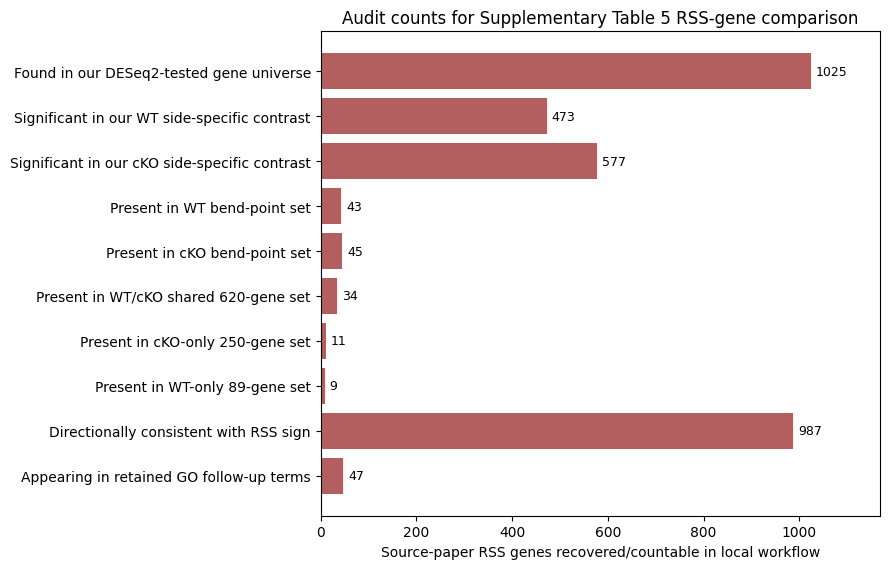

Wrote enhanced outputs to: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/preparation/DE-derived_analysis/source_paper_rss_comparison
- source_rss_agreement_statistics.tsv
- source_rss_apples_to_apples_comparison_panel.png
- source_rss_bendpoint_venn_style.png
- source_rss_branch_membership_matrix.tsv
- source_rss_cko_lfc_scatter.png
- source_rss_comparison_summary.md
- source_rss_comparison_summary.tsv
- source_rss_control_lfc_scatter.png
- source_rss_delta_scatter.png
- source_rss_direction_summary.tsv
- source_rss_gene_level_comparison.tsv
- source_rss_go_membership_overlap.tsv
- source_rss_go_term_comparison.tsv
- source_rss_go_term_overlap_scatter.png
- source_rss_go_term_specific_plot_terms.tsv
- source_rss_go_term_summary.tsv
- source_rss_membership_matrix.png
- source_rss_overlap_counts.png
- source_rss_plot_interpretation_notes.tsv


In [8]:

def dataframe_to_markdown(df):
    text_df = df.copy()
    columns = list(text_df.columns)
    rows = []
    rows.append('| ' + ' | '.join(columns) + ' |')
    rows.append('| ' + ' | '.join(['---'] * len(columns)) + ' |')
    for _, row in text_df.iterrows():
        rows.append('| ' + ' | '.join(str(row[col]) for col in columns) + ' |')
    return '\n'.join(rows)

gene_level_columns = [
    'source_gene_symbol', 'source_symbol_norm', 'gene_id', 'source_mapping_status', 'n_source_gene_ids',
    'source_log2fc_control', 'source_log2fc_cko', 'source_rss_shift', 'source_rss_sign',
    'our_log2fc_wt', 'our_log2fc_cko', 'our_delta_cko_minus_wt', 'our_delta_sign',
    'matched_our_tested_universe', 'source_padj_control', 'source_padj_cko', 'our_padj_wt', 'our_padj_cko',
    'significant_wt_side', 'significant_cko_side',
    'present_wt_bendpoint', 'present_cko_bendpoint', 'present_shared_bendpoint',
    'present_cko_only_bendpoint', 'present_wt_only_bendpoint',
    'direction_consistent_with_source_rss', 'appears_in_retained_go_terms', 'appears_in_anchor_gene_table',
]
comparison_gene_level = comparison_long.sort_values(['source_symbol_norm', 'gene_id'])[gene_level_columns]

summary.to_csv(OUTPUT_DIR / 'source_rss_comparison_summary.tsv', sep='\t', index=False)
direction_summary.to_csv(OUTPUT_DIR / 'source_rss_direction_summary.tsv', sep='\t', index=False)
comparison_gene_level.to_csv(OUTPUT_DIR / 'source_rss_gene_level_comparison.tsv', sep='\t', index=False)
go_overlap.to_csv(OUTPUT_DIR / 'source_rss_go_membership_overlap.tsv', sep='\t', index=False)
go_term_summary.to_csv(OUTPUT_DIR / 'source_rss_go_term_summary.tsv', sep='\t', index=False)

# Keep the original count audit plot, but no longer treat it as the main comparison figure.
plot_rows = summary[summary['metric'].isin([
    'Found in our DESeq2-tested gene universe',
    'Significant in our WT side-specific contrast',
    'Significant in our cKO side-specific contrast',
    'Present in WT bend-point set',
    'Present in cKO bend-point set',
    'Present in WT/cKO shared 620-gene set',
    'Present in cKO-only 250-gene set',
    'Present in WT-only 89-gene set',
    'Directionally consistent with RSS sign',
    'Appearing in retained GO follow-up terms',
])].copy()

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.barh(plot_rows['metric'], plot_rows['count'], color=PITER_RED)
ax.invert_yaxis()
ax.set_xlabel('Source-paper RSS genes recovered/countable in local workflow')
ax.set_title('Audit counts for Supplementary Table 5 RSS-gene comparison')
for y, value in enumerate(plot_rows['count']):
    ax.text(value + 10, y, f'{int(value)}', va='center', fontsize=9)
ax.set_xlim(0, max(plot_rows['count'].max() * 1.14, 100))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'source_rss_overlap_counts.png', dpi=300)
plt.show()

figure_notes = pd.DataFrame([
    {
        'figure': 'source_rss_apples_to_apples_comparison_panel.png',
        'role': 'Recommended main comparison figure',
        'what_it_shows': 'Source control/cKO/RSS values against our WT/cKO DESeq2 values, plus bend-point overlap in one compact panel.',
        'paper_use': 'Use when explaining direct validation of the pathway-level framework against source-paper RSS genes.',
    },
    {
        'figure': 'source_rss_bendpoint_venn_style.png',
        'role': 'Overlap explanation figure',
        'what_it_shows': 'How source RSS genes overlap WT/FF and cKO/CRE bend-point follow-up sets.',
        'paper_use': 'Use if the paper needs a simpler visual than the full multi-panel comparison.',
    },
    {
        'figure': 'source_rss_membership_matrix.png',
        'role': 'Interpretation matrix',
        'what_it_shows': 'Where positive and negative RSS genes land: shared bend-point, branch-specific bend-point, significant-only, tested-only, or unmatched.',
        'paper_use': 'Use in discussion/supporting material to explain why the comparison is meaningful but not a full reproduction.',
    },
    {
        'figure': 'source_rss_go_term_overlap_scatter.png',
        'role': 'Pathway-level bridge',
        'what_it_shows': 'Which non-generic retained GO/pathway terms contain source-paper RSS genes and how concentrated that support is.',
        'paper_use': 'Use when connecting source-study stress/growth themes to our retained GO interpretation.',
    },
    {
        'figure': 'source_rss_overlap_counts.png',
        'role': 'Audit/check figure',
        'what_it_shows': 'Simple count recovery across workflow stages.',
        'paper_use': 'Keep as a sanity-check output; not recommended as the main paper figure.',
    },
])
figure_notes.to_csv(OUTPUT_DIR / 'source_rss_plot_interpretation_notes.tsv', sep='\t', index=False)

md_lines = [
    '# Source-paper RSS gene-set comparison',
    '',
    f'Nature article: {ARTICLE_URL}',
    '',
    'This output compares Nature Supplementary Table 5 RSS genes against the local `mouse_new` DESeq2, bend-point, and retained GO follow-up outputs.',
    '',
    '## Why this revision uses more than one figure',
    '',
    'The first count-only plot was useful as an audit, but it did not make the source-study-versus-local-workflow comparison easy to understand. The revised figure set follows the transcript guidance to keep the story focused, compare at gene-support level where possible, and use only visuals that clarify the interpretation.',
    '',
    '## Paper-ready count table',
    '',
    dataframe_to_markdown(summary),
    '',
    '## Direction breakdown',
    '',
    dataframe_to_markdown(direction_summary),
    '',
    '## Recommended figure set',
    '',
    dataframe_to_markdown(figure_notes),
    '',
    '## Agreement statistics',
    '',
    dataframe_to_markdown(agreement_stats.round(4).fillna('')),
    '',
    '## Branch-membership matrix',
    '',
    dataframe_to_markdown(membership_matrix.reset_index().rename(columns={membership_matrix.index.name or 'index': 'analysis_membership'})),
    '',
    '## Interpretation guardrail',
    '',
    'This is a direct gene-set comparison, not proof that our pipeline reproduces the source paper exactly. The source study used RSS over PL-DEGs, whereas this project used DESeq2 side-specific contrasts, bend-point narrowing, and retained GO memberships. The appropriate paper claim is that the source-paper RSS set is largely present in our tested universe, directionally consistent with our RSS-like cKO-minus-WT delta for most matched genes, only partly retained by bend-point follow-up, and strongest as a validation/interpretation bridge rather than a replacement for our pathway-level analysis.',
    '',
    '## Checklist status',
    '',
    'OPEN / IN PROGRESS - The real analysis table and comparison figures have now been generated, but the manuscript item should remain open until a Results/Discussion paragraph is inserted and reviewed in the paper draft.',
]
(OUTPUT_DIR / 'source_rss_comparison_summary.md').write_text('\n'.join(md_lines))

print('Wrote enhanced outputs to:', OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.glob('source_rss_*')):
    print('-', path.name)


## 7. Paper-facing interpretation draft

Use this only after checking the generated tables and deciding where it belongs in Results/Discussion.

> To compare our DESeq2 + bend-point workflow with the source study's response-shift score (RSS) analysis, we matched the 1,431 AhR-responsive genes from Supplementary Table 5 against our tested gene universe, side-specific contrasts, bend-point sets, and retained GO memberships. The revised comparison showed that most source RSS genes were present in our DESeq2-tested universe and that most matched genes had the same RSS-like direction when comparing the source-paper RSS sign with our cKO-minus-WT log2FC delta. Only a smaller subset entered the stricter WT/FF and CRE/cKO bend-point follow-up sets, which is expected because the bend-point procedure intentionally narrows the larger DESeq2 result to the strongest local signal. This supports an apples-to-apples interpretation in which our pathway-level analysis captures part of the source study's AhR-dependent response-shift signal while remaining a distinct DESeq2-based reanalysis rather than a full reproduction of the original RSS pipeline.

**Keep open until paper text is inserted.** The notebook generates the analysis output; it does not by itself finish the manuscript revision.